In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             PrecisionRecallDisplay, RocCurveDisplay)

columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df = pd.read_csv('wdbcdata.csv', header=None, names=columns)


le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis']) # M -> 1, B -> 0


X = df.drop(['ID', 'Diagnosis'], axis=1)
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Experiment 1: Naïve Bayes

Accuracy: 0.9737

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        71
           1       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



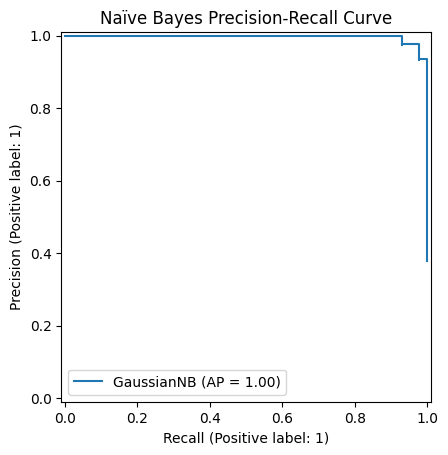

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))


PrecisionRecallDisplay.from_estimator(nb_model, X_test, y_test)
plt.title("Naïve Bayes Precision-Recall Curve")
plt.show()

In [ ]:
#Experiment 2: Decision Tree

Accuracy: 0.9474


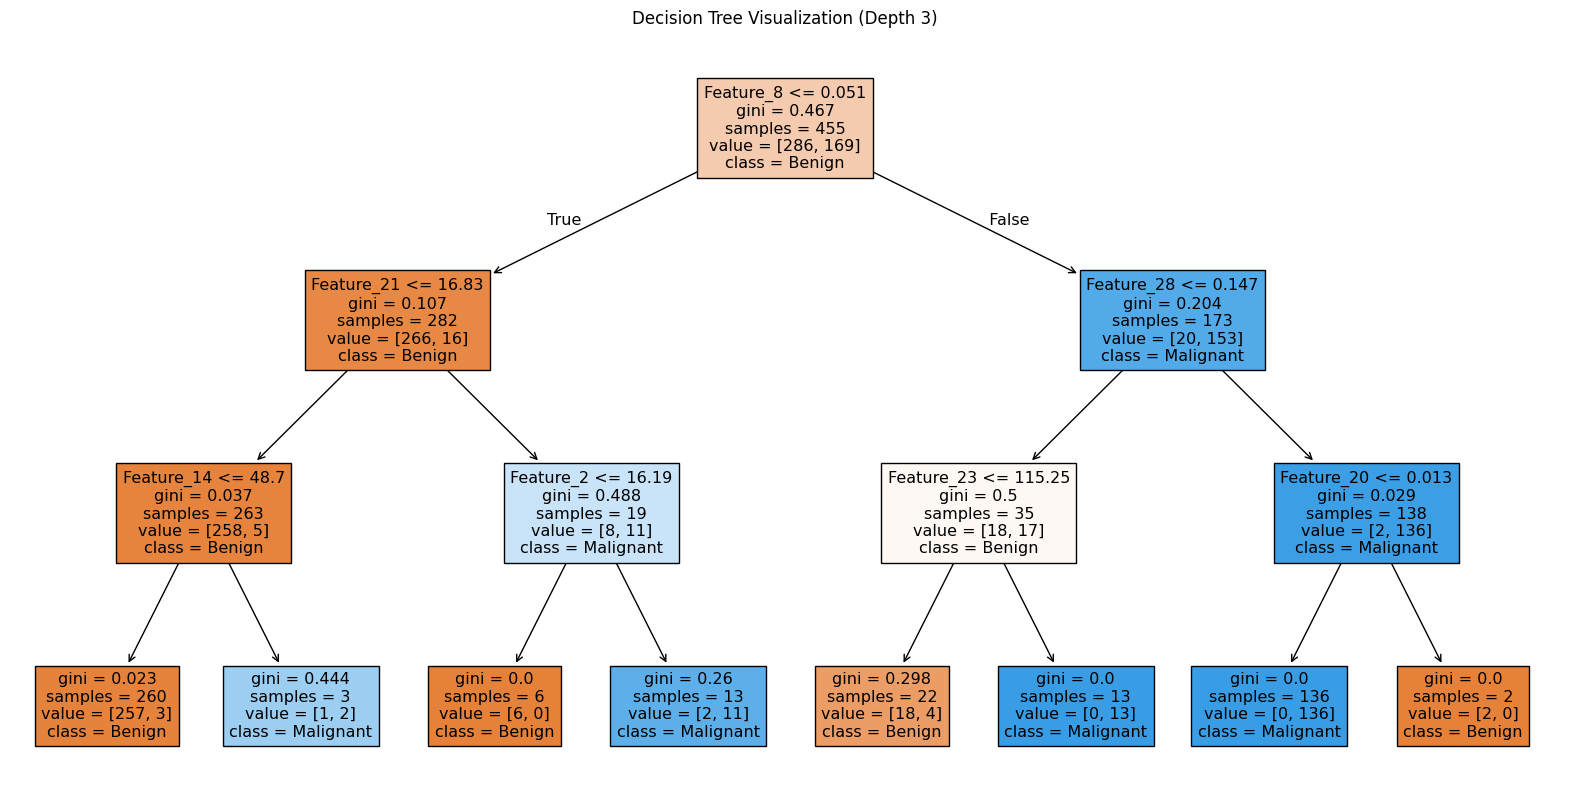

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")


plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.title("Decision Tree Visualization (Depth 3)")
plt.show()

In [ ]:
#Experiment 3: Comparison & Visualization

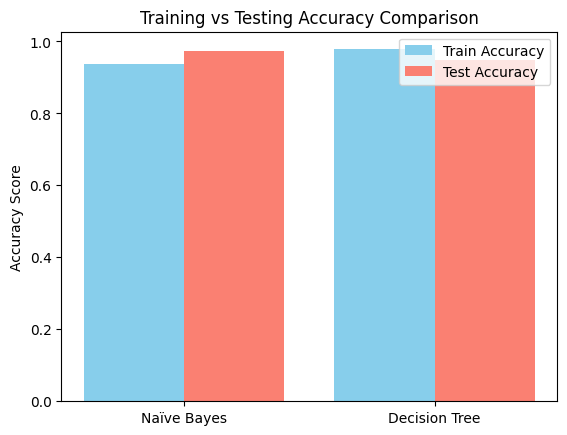

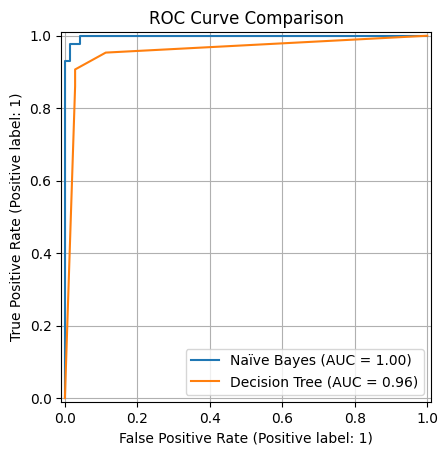

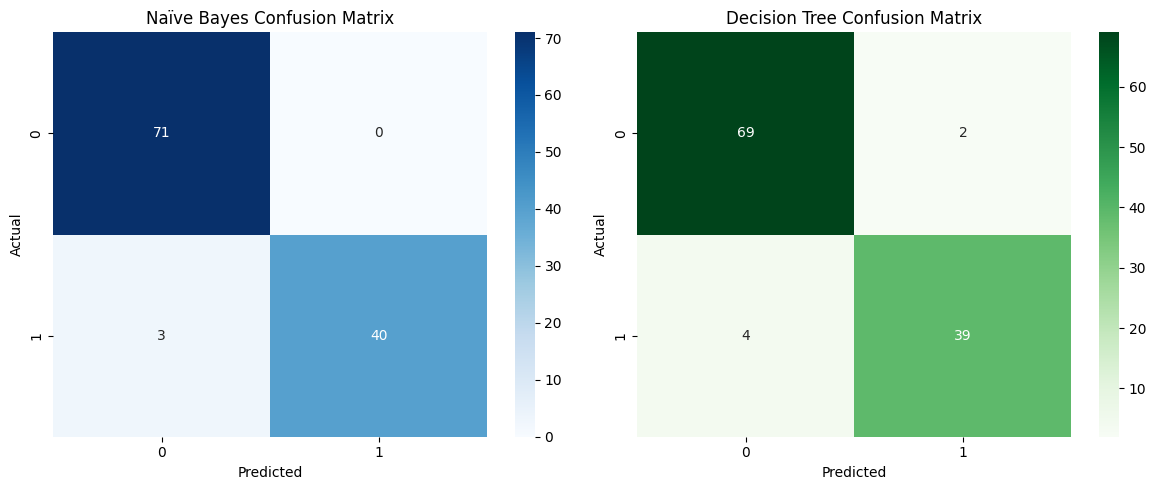

In [ ]:
models = ['Naïve Bayes', 'Decision Tree']
train_acc = [accuracy_score(y_train, nb_model.predict(X_train)),
             accuracy_score(y_train, dt_model.predict(X_train))]
test_acc = [accuracy_score(y_test, y_pred_nb),
            accuracy_score(y_test, y_pred_dt)]

x_axis = np.arange(len(models))
plt.bar(x_axis - 0.2, train_acc, 0.4, label='Train Accuracy', color='skyblue')
plt.bar(x_axis + 0.2, test_acc, 0.4, label='Test Accuracy', color='salmon')
plt.xticks(x_axis, models)
plt.ylabel("Accuracy Score")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.show()



ax = plt.gca()
RocCurveDisplay.from_estimator(nb_model, X_test, y_test, ax=ax, name='Naïve Bayes')
RocCurveDisplay.from_estimator(dt_model, X_test, y_test, ax=ax, name='Decision Tree')
plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title("Naïve Bayes Confusion Matrix")
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', ax=ax2, cmap='Greens')
ax2.set_title("Decision Tree Confusion Matrix")
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")

plt.tight_layout()
plt.show()